Setup and Configuration

In [ ]:
import os
import time
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

import warnings
warnings.filterwarnings("ignore")

IS_KAGGLE = "KAGGLE_KERNEL_INTEGRATIONS_METADATA" in os.environ

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'}")

Device: cuda
Environment: Local


Config

In [29]:
class CFG:
    # --- Paths ---
    COMP_DIR   = "kaggle/input/competitions/leonardo-airborne-object-recognition-challenge"
    TRAIN_DIR  = f"{COMP_DIR}/train"
    TEST_DIR   = f"{COMP_DIR}/test"
    TRAIN_CSV  = f"{COMP_DIR}/train.csv"
    SAMPLE_SUB = f"{COMP_DIR}/sample_submission.csv"
    WORK_DIR   = "kaggle/working"

    # Path to pretrained weights (uploaded as Kaggle Dataset)
    WEIGHTS_PATH = "kaggle/input/notebooks/pestipeti/pytorch-starter-fasterrcnn-train/fasterrcnn_resnet50_fpn.pth"

    # --- Classes ---
    # Faster R-CNN reserves 0 for background, so our classes are 1-7
    CLASSES     = ["Aircraft", "Helicopter", "Drone", "GroundVehicle",
                   "Ship", "Human", "Obstacle"]
    NUM_CLASSES = 7
    CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}       # 0-based
    IDX2CLASS   = {i: c for i, c in enumerate(CLASSES)}        # 0-based

    # --- Training ---
    IMG_SIZE    = 640
    BATCH_SIZE  = 4
    EPOCHS      = 10 # For baseline
    LR          = 1e-4
    SEED        = 42
    N_FOLDS     = 5
    FOLD        = 0

    # --- Inference ---
    CONF_THRESH = 0.05
    IOU_THRESH  = 0.5
    MAX_DET     = 300

Download model (turn off internet after download success)

In [30]:
if Path("fasterrcnn.pth").exists():
    print("✓ Pretrained weights already exist. Skipping download.")
else:
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT"
    )

    torch.save(model.state_dict(), "fasterrcnn.pth")

✓ Pretrained weights already exist. Skipping download.


Exploratory Data Analysis

In [31]:
df = pd.read_csv(CFG.TRAIN_CSV)

# Parse bounding boxes from string to columns
bbox_cols = df["bbox"].str.split(" ", expand=True).astype(float)
bbox_cols.columns = ["x_min", "y_min", "x_max", "y_max"]
df = pd.concat([df, bbox_cols], axis=1)

df["bbox_w"] = df["x_max"] - df["x_min"]
df["bbox_h"] = df["y_max"] - df["y_min"]
df["bbox_area"] = df["bbox_w"] * df["bbox_h"]

print(f"Total annotations: {len(df):,}")
print(f"Total images:      {df['ImageId'].nunique():,}")
print(f"Avg objects/image: {len(df) / df['ImageId'].nunique():.1f}")

Total annotations: 72,319
Total images:      17,406
Avg objects/image: 4.2


Class Distribution

class
GroundVehicle    25974
Human            13828
Obstacle         13224
Ship             13100
Drone             2494
Aircraft          2190
Helicopter        1509
Name: count, dtype: int64
class
GroundVehicle    35.915873
Human            19.120840
Obstacle         18.285651
Ship             18.114189
Drone             3.448610
Aircraft          3.028250
Helicopter        2.086589
Name: count, dtype: float64


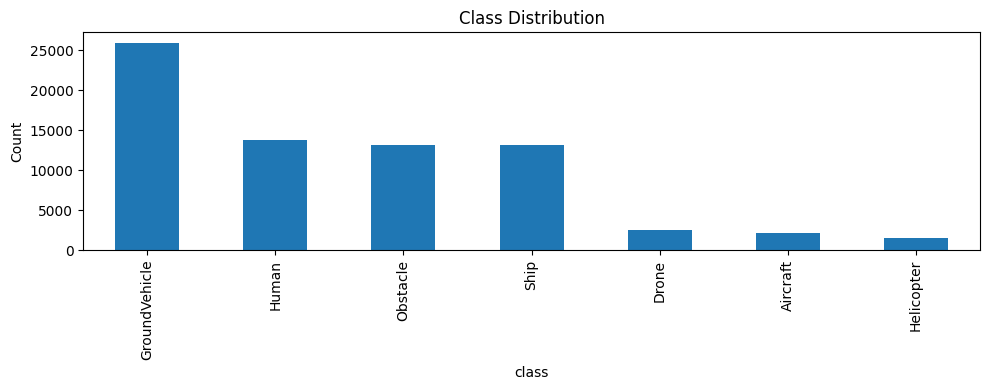

In [32]:
class_counts = df["class"].value_counts()
print(class_counts)
print(class_counts / len(df) * 100)  # percentages

class_counts.plot(kind="bar", figsize=(10, 4), title="Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Bbox Size per Class

In [33]:
print(f"{'Class':20s} {'Width':>8s} {'Height':>8s} {'Area':>10s}")
print("-" * 50)
for cls in CFG.CLASSES:
    sub = df[df["class"] == cls]
    if len(sub) == 0:
        continue
    print(f"{cls:20s} {sub['bbox_w'].median():8.4f} {sub['bbox_h'].median():8.4f} "
          f"{sub['bbox_area'].median():10.6f}")

Class                   Width   Height       Area
--------------------------------------------------
Aircraft               0.1550   0.1264   0.019181
Helicopter             0.1506   0.1267   0.019688
Drone                  0.0283   0.0289   0.000806
GroundVehicle          0.0337   0.0410   0.001412
Ship                   0.0390   0.0437   0.001743
Human                  0.0175   0.0512   0.000919
Obstacle               0.0178   0.1037   0.001834


RGB vs IR Detection

In [34]:
sample_ids = df["ImageId"].unique()[:300]
rgb_count, ir_count = 0, 0

for img_id in sample_ids:
    img_path = os.path.join(CFG.TRAIN_DIR, f"{img_id}.png")
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue

    # If all 3 channels are nearly identical → grayscale/IR
    b, g, r = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    mean_diff = (np.mean(np.abs(b.astype(float) - g.astype(float))) +
                 np.mean(np.abs(b.astype(float) - r.astype(float)))) / 2
    if mean_diff < 3.0:
        ir_count += 1
    else:
        rgb_count += 1

total = rgb_count + ir_count
print(f"RGB: {rgb_count} ({rgb_count/total*100:.1f}%)")
print(f"IR:  {ir_count} ({ir_count/total*100:.1f}%)")

RGB: 216 (72.0%)
IR:  84 (28.0%)


Image Sizes

In [35]:
sizes = []
for img_id in sample_ids[:100]:
    img = cv2.imread(os.path.join(CFG.TRAIN_DIR, f"{img_id}.png"))
    if img is not None:
        h, w = img.shape[:2]
        sizes.append((w, h))

size_counts = Counter(sizes)
for sz, cnt in size_counts.most_common(10):
    print(f"  {sz[0]}×{sz[1]}: {cnt} images")

  1440×810: 22 images
  960×540: 14 images
  1760×990: 5 images
  1576×886: 5 images
  1364×767: 3 images
  1427×803: 3 images
  2040×1530: 3 images
  1672×940: 3 images
  1538×865: 3 images
  1181×886: 2 images


Visualize Samples

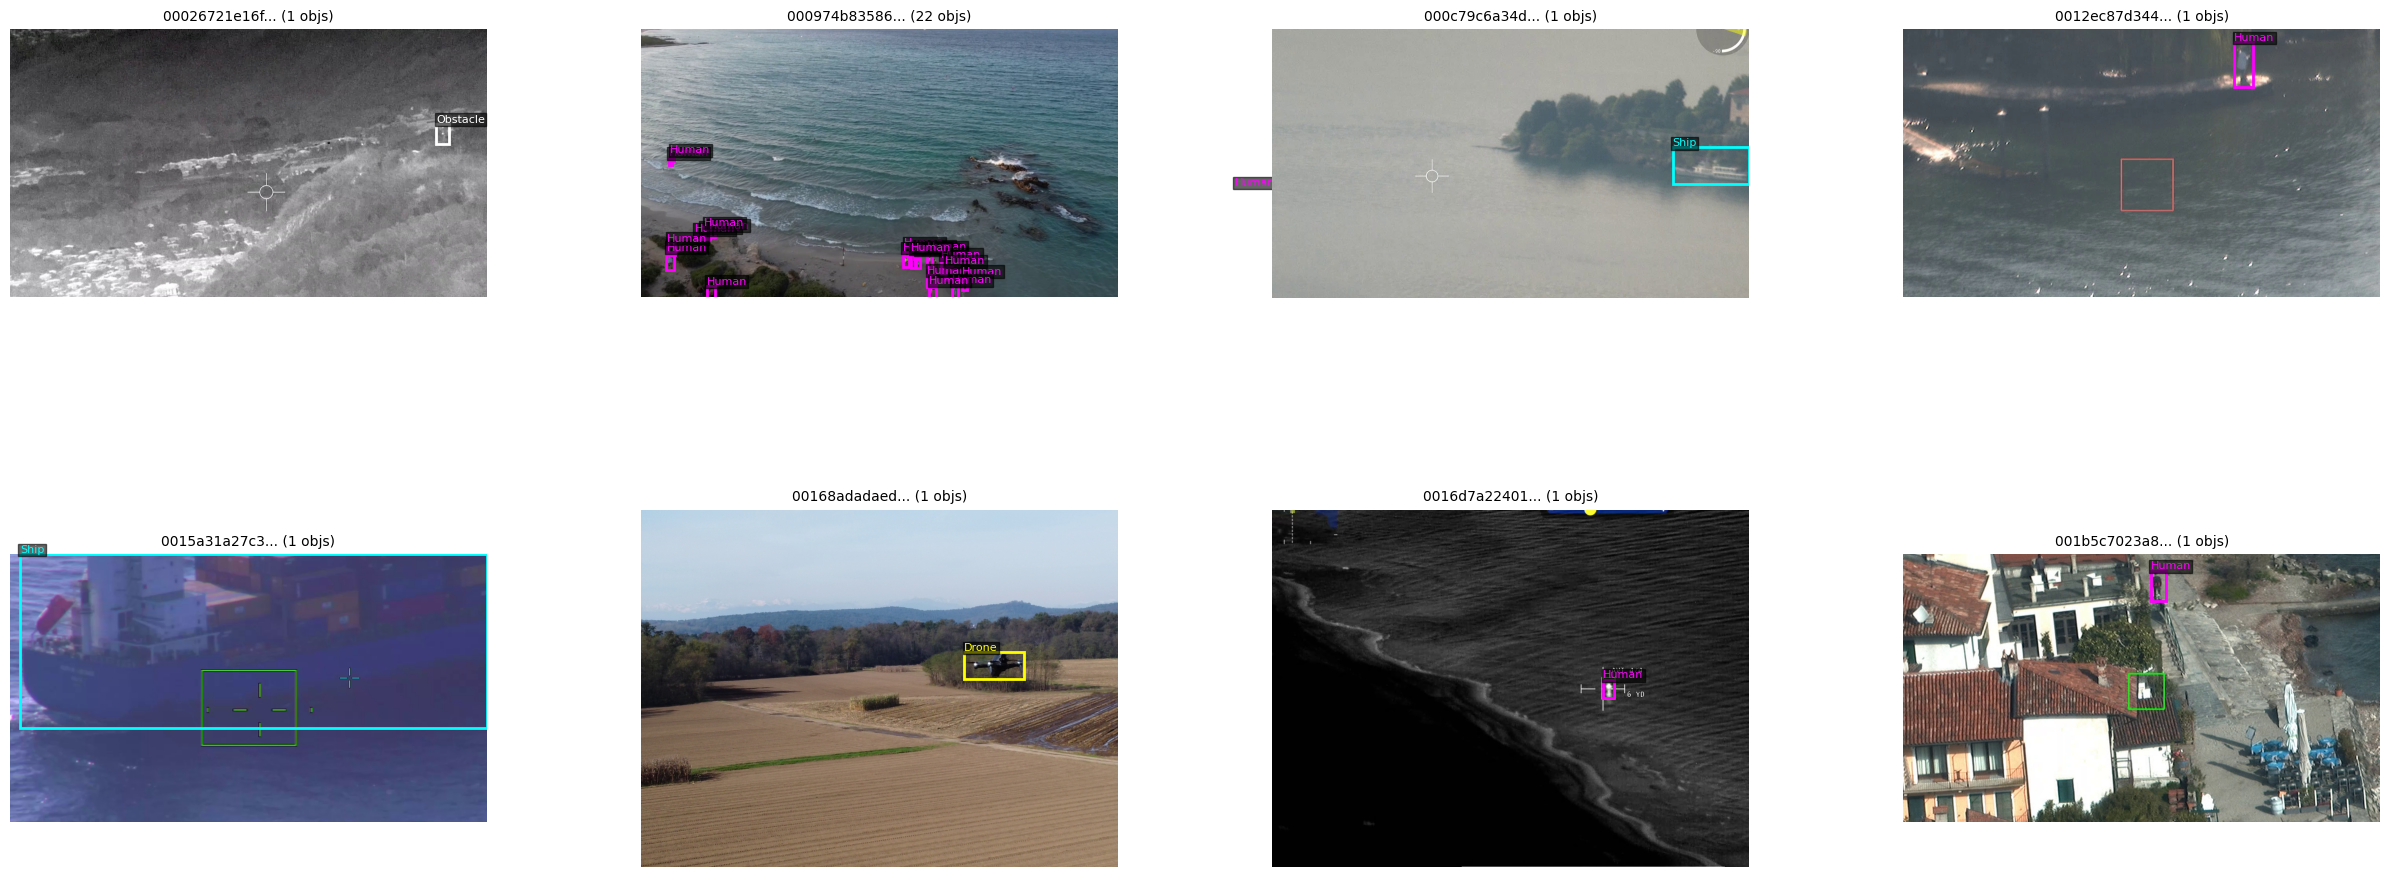

In [36]:
COLOR_MAP = {
    "Aircraft": "red", "Helicopter": "orange", "Drone": "yellow",
    "GroundVehicle": "lime", "Ship": "cyan", "Human": "magenta",
    "Obstacle": "white",
}

sample_images = df["ImageId"].unique()[:8]
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for idx, img_id in enumerate(sample_images):
    ax = axes[idx // 4][idx % 4]
    img = cv2.imread(os.path.join(CFG.TRAIN_DIR, f"{img_id}.png"))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    anns = df[df["ImageId"] == img_id]
    for _, row in anns.iterrows():
        x1, y1 = row["x_min"] * w, row["y_min"] * h
        bw = (row["x_max"] - row["x_min"]) * w
        bh = (row["y_max"] - row["y_min"]) * h
        color = COLOR_MAP.get(row["class"], "white")
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2,
                                 edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, row["class"], color=color, fontsize=8,
                bbox=dict(facecolor="black", alpha=0.6, pad=1))
    ax.set_title(f"{img_id[:12]}... ({len(anns)} objs)", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

Data Preparation

In [37]:
df = pd.read_csv(CFG.TRAIN_CSV)

bbox_cols = df["bbox"].str.split(" ", expand=True).astype(float)
bbox_cols.columns = ["x_min", "y_min", "x_max", "y_max"]
df = pd.concat([df, bbox_cols], axis=1)


# Convert YOLO format
df["yolo_x"] = ((df["x_min"] + df["x_max"]) / 2).clip(0, 1)
df["yolo_y"] = ((df["y_min"] + df["y_max"]) / 2).clip(0, 1)
df["yolo_w"] = (df["x_max"] - df["x_min"]).clip(0, 1)
df["yolo_h"] = (df["y_max"] - df["y_min"]).clip(0, 1)

df["class_idx"] = df["class"].map(CFG.CLASS2IDX)

# remove invalid
df = df[(df["yolo_w"] > 1e-5) & (df["yolo_h"] > 1e-5)].reset_index(drop=True)

In [38]:
class DetectionDataset(Dataset):
    """
    Dataset for Faster R-CNN.
    - Resizes images to IMG_SIZE (keeping aspect ratio via padding or squish)
    - Converts relative bbox coords to absolute pixel coords after resize
    - Labels are 1-indexed (0 = background for Faster R-CNN)
    """

    def __init__(self, df, image_ids, img_dir, img_size=640):
        self.df = df
        self.image_ids = list(image_ids)
        self.img_dir = img_dir
        self.img_size = img_size

        # Pre-group annotations by ImageId for faster lookup
        self.annotations = {}
        for img_id in self.image_ids:
            self.annotations[img_id] = df[df["ImageId"] == img_id]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        # Read and resize image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        anns = self.annotations[img_id]

        boxes = []
        labels = []
        for _, row in anns.iterrows():
            # Bbox coords are relative (0-1) → scale to resized image pixels
            x1 = row["x_min"] * self.img_size
            y1 = row["y_min"] * self.img_size
            x2 = row["x_max"] * self.img_size
            y2 = row["y_max"] * self.img_size

            # Skip degenerate boxes
            if x2 - x1 < 1 or y2 - y1 < 1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(row["class_idx"] + 1)  # +1 because 0 = background

        # Handle images with no valid boxes
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        img_tensor = T.ToTensor()(img)  # HWC uint8 → CHW float [0,1]
        return img_tensor, target

Stratified K-Fold Split

In [39]:
# Add class_idx column (needed by Dataset)
df["class_idx"] = df["class"].map(CFG.CLASS2IDX)

# Remove invalid boxes
df = df[
    ((df["x_max"] - df["x_min"]) > 1e-5) &
    ((df["y_max"] - df["y_min"]) > 1e-5)
].reset_index(drop=True)

# Stratified K-Fold by dominant class per image
img_df = df.groupby("ImageId").agg(
    dominant_class=("class", lambda x: x.value_counts().index[0]),
).reset_index()

skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
img_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(img_df, img_df["dominant_class"])):
    img_df.loc[val_idx, "fold"] = fold_idx

In [40]:
import random

train_ids = img_df[img_df["fold"] != CFG.FOLD]["ImageId"].tolist()
val_ids   = img_df[img_df["fold"] == CFG.FOLD]["ImageId"].tolist()
print(f"Fold {CFG.FOLD}: {len(train_ids)} train, {len(val_ids)} val")
# train_ids = random.sample(list(train_ids), 2000)


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = DetectionDataset(df, train_ids, CFG.TRAIN_DIR, CFG.IMG_SIZE)
val_dataset   = DetectionDataset(df, val_ids,   CFG.TRAIN_DIR, CFG.IMG_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True,
)

Fold 0: 13924 train, 3482 val


Training Pipeline

In [42]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Build model without pretrained weights (offline)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None,
)

# Load pretrained checkpoint, excluding the classification head
state_dict = torch.load(CFG.WEIGHTS_PATH, map_location="cpu")
state_dict = {
    k: v for k, v in state_dict.items()
    if "roi_heads.box_predictor" not in k
}
model.load_state_dict(state_dict, strict=False)

# Replace head: 7 classes + 1 background = 8
num_classes = CFG.NUM_CLASSES + 1
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
print(f"Model ready on {device}")

Model ready on cuda


Training Loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

log_interval = 100

for epoch in range(CFG.EPOCHS):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()

    for step, (images, targets) in enumerate(train_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if step % log_interval == 0:
            elapsed = time.time() - start_time
            eta = (elapsed / (step + 1)) * (len(train_loader) - step - 1)
            loss_str = " | ".join(f"{k}: {v.item():.3f}" for k, v in loss_dict.items())
            print(f"  [Epoch {epoch+1}/{CFG.EPOCHS}] Step {step}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | {loss_str} | "
                  f"ETA: {eta/60:.1f} min")

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    elapsed = (time.time() - start_time) / 60
    print(f"  Epoch {epoch+1} done | Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f} min | LR: {scheduler.get_last_lr()[0]:.6f}\n")

# Save model
torch.save(model.state_dict(), f"{CFG.WORK_DIR}/fasterrcnn_fold{CFG.FOLD}.pth")
print("Model saved!")

  [Epoch 1/10] Step 0/3481 | Loss: 3.5708 | loss_classifier: 2.572 | loss_box_reg: 0.037 | loss_objectness: 0.941 | loss_rpn_box_reg: 0.020 | ETA: 199.4 min
  [Epoch 1/10] Step 100/3481 | Loss: 0.4260 | loss_classifier: 0.146 | loss_box_reg: 0.109 | loss_objectness: 0.107 | loss_rpn_box_reg: 0.063 | ETA: 30.5 min
  [Epoch 1/10] Step 200/3481 | Loss: 0.4428 | loss_classifier: 0.136 | loss_box_reg: 0.111 | loss_objectness: 0.117 | loss_rpn_box_reg: 0.078 | ETA: 28.5 min
  [Epoch 1/10] Step 300/3481 | Loss: 0.2328 | loss_classifier: 0.094 | loss_box_reg: 0.091 | loss_objectness: 0.034 | loss_rpn_box_reg: 0.013 | ETA: 27.4 min
  [Epoch 1/10] Step 400/3481 | Loss: 0.4078 | loss_classifier: 0.173 | loss_box_reg: 0.129 | loss_objectness: 0.070 | loss_rpn_box_reg: 0.036 | ETA: 26.3 min
  [Epoch 1/10] Step 500/3481 | Loss: 0.6522 | loss_classifier: 0.244 | loss_box_reg: 0.281 | loss_objectness: 0.071 | loss_rpn_box_reg: 0.057 | ETA: 25.4 min
  [Epoch 1/10] Step 600/3481 | Loss: 0.1813 | loss_cl

Inference & Submission

In [ ]:
model.eval()
predictions = {}

test_images = sorted(Path(CFG.TEST_DIR).glob("*.png"))
print(f"Running inference on {len(test_images)} test images...")

with torch.no_grad():
    for i, img_path in enumerate(test_images):
        img_id = img_path.stem

        # Read and resize (same as training)
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]
        img_resized = cv2.resize(img, (CFG.IMG_SIZE, CFG.IMG_SIZE))

        img_tensor = T.ToTensor()(img_resized).to(device)
        outputs = model([img_tensor])[0]

        preds = []
        for box, score, label in zip(outputs["boxes"], outputs["scores"], outputs["labels"]):
            if score.item() < CFG.CONF_THRESH:
                continue

            x1, y1, x2, y2 = box.cpu().numpy()

            # Convert from resized pixel coords back to relative [0, 1]
            x1_rel = float(np.clip(x1 / CFG.IMG_SIZE, 0, 1))
            y1_rel = float(np.clip(y1 / CFG.IMG_SIZE, 0, 1))
            x2_rel = float(np.clip(x2 / CFG.IMG_SIZE, 0, 1))
            y2_rel = float(np.clip(y2 / CFG.IMG_SIZE, 0, 1))

            # label is 1-indexed (1-7), convert to class name via 0-indexed map
            cls_name = CFG.IDX2CLASS[label.item() - 1]
            preds.append((cls_name, float(score), x1_rel, y1_rel, x2_rel, y2_rel))

        predictions[img_id] = preds

        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(test_images)}")

print(f"Inference done! {len(predictions)} images processed.")

In [ ]:
# Get all required test image IDs
sample_sub = pd.read_csv(CFG.SAMPLE_SUB)
required_ids = set(sample_sub["ImageId"].tolist())

# Also check test folder for any IDs not in sample
test_dir_ids = {p.stem for p in Path(CFG.TEST_DIR).glob("*.png")}
all_test_ids = sorted(required_ids | test_dir_ids)

print(f"Sample sub IDs: {len(required_ids)}")
print(f"Test dir IDs:   {len(test_dir_ids)}")
print(f"Total test IDs: {len(all_test_ids)}")

rows = []
for img_id in all_test_ids:
    preds = predictions.get(img_id, [])

    if len(preds) == 0:
        pred_str = "None 1 -1 -1 -1 -1"
    else:
        # Sort by confidence descending, keep top MAX_DET
        preds = sorted(preds, key=lambda x: -x[1])[:CFG.MAX_DET]
        parts = []
        for label, conf, x1, y1, x2, y2 in preds:
            parts.append(f"{label} {conf:.4f} {x1:.6f} {y1:.6f} {x2:.6f} {y2:.6f}")
        pred_str = " ".join(parts)

    rows.append({"ImageId": img_id, "PredictionString": pred_str})

sub_df = pd.DataFrame(rows)
sub_df.to_csv("submission.csv", index=False)

# Sanity checks
n_with_det = (sub_df["PredictionString"] != "None 1 -1 -1 -1 -1").sum()
print(f"\nSubmission saved: submission.csv")
print(f"  Total rows:       {len(sub_df)}")
print(f"  With detections:  {n_with_det} ({n_with_det/len(sub_df)*100:.1f}%)")
print(f"  No detections:    {len(sub_df) - n_with_det}")
print(f"\nFirst 5 rows:")
print(sub_df.head().to_string(index=False))